# 03 Feature Extraction Single Sample

Computes Welch PSD features for one preprocessed subject and visualizes the PSD, relative normalization, and optional log-PSD output.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt

from dataset_loader import create_subject_metadata
from feature_extraction import compute_welch_psd
from preprocessing import preprocess_subject
from utils import RAW_DATASET_DIR

In [2]:
metadata_df = create_subject_metadata(RAW_DATASET_DIR, verbose=False)
sample_row = metadata_df.iloc[0]
preprocessed = preprocess_subject(sample_row['eeg_file'])
epoch_array = preprocessed['epoch_array']
sfreq = preprocessed['raw'].info['sfreq']

psd_features, freqs = compute_welch_psd(epoch_array, sfreq=sfreq)
log_psd_features, _ = compute_welch_psd(epoch_array, sfreq=sfreq, log_transform=True)

print('PSD shape:', psd_features.shape)
print('Frequency bins:', freqs.shape)
print('First 10 frequencies:', freqs[:10])

PSD shape: (138, 19, 89)
Frequency bins: (89,)
First 10 frequencies: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]


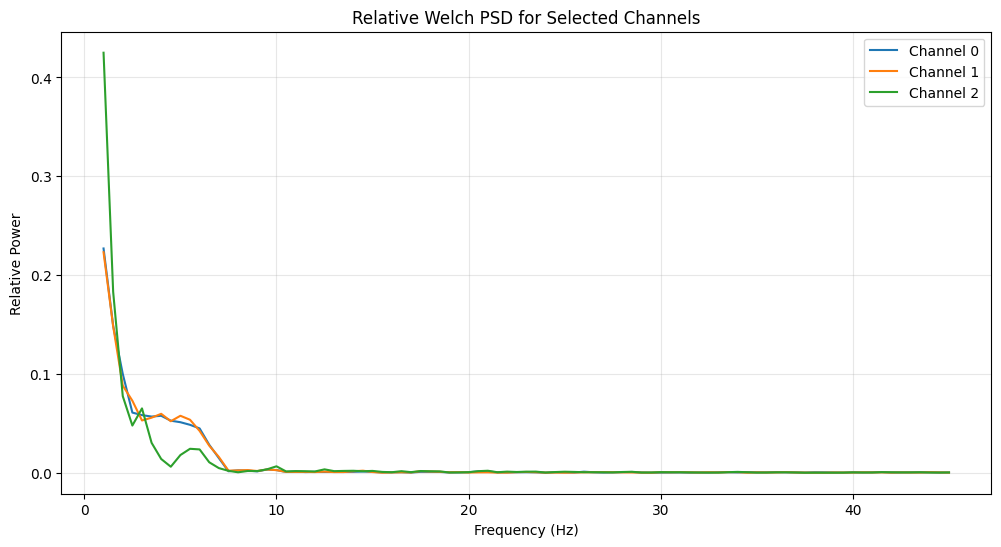

In [3]:
epoch_idx = 0
channel_indices = [0, min(1, psd_features.shape[1] - 1), min(2, psd_features.shape[1] - 1)]

fig, ax = plt.subplots(figsize=(12, 6))
for channel_idx in channel_indices:
    ax.plot(freqs, psd_features[epoch_idx, channel_idx], label=f'Channel {channel_idx}')
ax.set_title('Relative Welch PSD for Selected Channels')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Relative Power')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## PSD Interpretation Note

- Low-frequency dominance is often observed because EEG usually contains stronger slow-wave power than high-frequency power.
- Relative normalization means the PSD values are scaled by total power, so each frequency bin shows its proportion of the overall signal power.
- PSD is useful for classification because it converts EEG into stable frequency-domain patterns that can differ across disease groups.

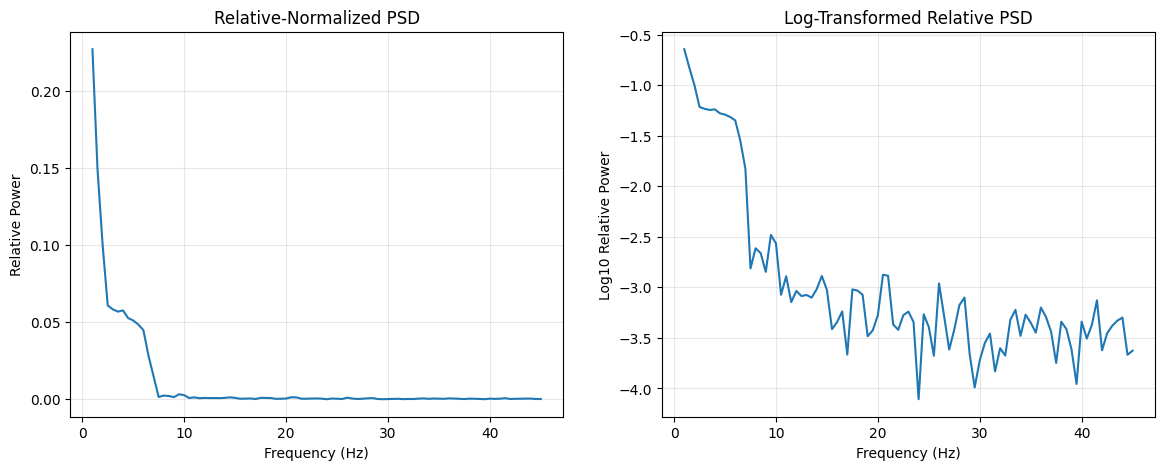

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
axes[0].plot(freqs, psd_features[epoch_idx, 0])
axes[0].set_title('Relative-Normalized PSD')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Relative Power')
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, log_psd_features[epoch_idx, 0])
axes[1].set_title('Log-Transformed Relative PSD')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Log10 Relative Power')
axes[1].grid(True, alpha=0.3)
plt.show()